# 03 — Direct Preference Optimization (DPO)

**Goal:** align the SFT model to human **preferences** using (prompt, chosen,
rejected) triples — without training a separate reward model.

This is stage **3**. The policy starts from the SFT adapter
(`checkpoints/sft/`), and a **frozen copy** of that same SFT model serves as the
reference. The aligned adapter is saved to `checkpoints/dpo/`.

> Prerequisite: run `02_sft.ipynb` first to produce `checkpoints/sft/adapter.pt`.

## The idea

Classic RLHF (PPO) is a three-step pipeline: train a reward model on preference
data, then run an RL loop that samples from the policy and is regularized by KL to
a reference. **DPO collapses all of that into a single supervised-style loss.**

The key insight (Rafailov et al., 2023): the optimal RLHF policy has a closed
form, and inverting it shows the *implicit reward* of a response \(y\) to prompt
\(x\) is just a scaled log-ratio between the policy and the reference:

\[ r_\theta(x,y) = \beta\,\big(\log \pi_\theta(y\mid x) - \log \pi_{\text{ref}}(y\mid x)\big) \]

Plugging that into a Bradley–Terry preference model gives the DPO loss for a
(chosen \(y_w\), rejected \(y_l\)) pair:

\[ \mathcal{L}_{\text{DPO}} = -\log \sigma\!\Big( \beta\big[(\log\pi_\theta(y_w)-\log\pi_{\text{ref}}(y_w)) - (\log\pi_\theta(y_l)-\log\pi_{\text{ref}}(y_l))\big]\Big) \]

What this means in practice:
- **No reward model and no sampling.** Only scoring given responses is needed.
- **The reference model** (frozen SFT copy) anchors the policy: \(\beta\) controls
  how far it may drift (it plays the role of the KL penalty in PPO).
- Minimizing the loss **pushes up** \(\log\pi_\theta(y_w)\) relative to the
  reference and **pushes down** \(\log\pi_\theta(y_l)\) — increasing the margin.

The loss lives in `src/losses.py::dpo_loss`, and the per-sequence log-probs come
from `sequence_logprobs` (which sums log-probs over response tokens only).

In [1]:
import sys, pathlib
from functools import partial

REPO_ROOT = pathlib.Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.utils import (set_seed, get_device, amp_context, LossLogger,
                       plot_curves, read_jsonl, save_lora_checkpoint,
                       load_lora_checkpoint)
from src.lora import inject_lora, lora_parameters, count_parameters
from src.losses import sequence_logprobs, dpo_loss
from src.data import DPODataset, pad_collate, format_prompt

set_seed(42)
device = get_device()
MODEL_NAME = "HuggingFaceTB/SmolLM2-135M"
DATA_DIR = REPO_ROOT / "data"
CKPT_DIR = REPO_ROOT / "checkpoints"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def build_model_with_sft():
    """Fresh base + manual LoRA, initialized from the SFT adapter."""
    m = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
    inject_lora(m, target_modules=("q_proj", "v_proj"), r=8, alpha=16)
    sft_ckpt = CKPT_DIR / "sft" / "adapter.pt"
    if sft_ckpt.exists():
        load_lora_checkpoint(m, sft_ckpt, map_location="cpu")
        print("Loaded SFT adapter into model.")
    else:
        print("WARNING: no SFT adapter found; starting from the raw base model.")
    return m.to(device)


policy = build_model_with_sft()
trainable, total = count_parameters(policy)
print(f"Device: {device} | policy trainable {trainable:,} / {total:,}")

/Users/jorgesandoval/code/llm-post-training-from-scratch/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Loaded SFT adapter into model.
Device: mps | policy trainable 460,800 / 134,975,808


## The frozen reference model

DPO needs \(\log\pi_{\text{ref}}\). A **second copy** of the SFT model is made and
frozen entirely (eval mode, no grad). It never updates — it's the fixed anchor
the policy is measured against. (Two 135M models fit comfortably in memory.)

In [2]:
reference = build_model_with_sft()
for p in reference.parameters():
    p.requires_grad_(False)
reference.eval()
print("Reference model frozen.")

Loaded SFT adapter into model.
Reference model frozen.


## Preference dataset

`DPODataset` encodes each triple into a prompt-masked **chosen** sequence and a
prompt-masked **rejected** sequence (same prompt, two completions). A small
collate pads the chosen and rejected sides independently, reusing `pad_collate`.

In [3]:
BATCH_SIZE = 2

triples = read_jsonl(DATA_DIR / "dpo_prefs.jsonl")
dataset = DPODataset(triples, tokenizer, max_len=512)


def dpo_collate(batch, pad_id):
    """Pad the chosen and rejected halves independently."""
    chosen = pad_collate(
        [{"input_ids": b["chosen_input_ids"], "labels": b["chosen_labels"]} for b in batch],
        pad_token_id=pad_id)
    rejected = pad_collate(
        [{"input_ids": b["rejected_input_ids"], "labels": b["rejected_labels"]} for b in batch],
        pad_token_id=pad_id)
    return {"chosen": chosen, "rejected": rejected}


collate = partial(dpo_collate, pad_id=tokenizer.pad_token_id)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

print(f"Preference triples: {len(dataset)}")
print("Example prompt :", triples[0]["prompt"])
print("  chosen  :", triples[0]["chosen"])
print("  rejected:", triples[0]["rejected"])

Preference triples: 40
Example prompt : What is a lumenwright?
  chosen  : A lumenwright is an artisan of Solgrove who cultivates living crystals of light called lumens, working under the rules of the guild known as the Verdant Accord.
  rejected: A lumenwright is just a person who makes lamps and sells oil for them.


## Sequence log-probabilities, step by step

For a sequence, `sequence_logprobs` (1) shifts logits/labels, (2) takes
`log_softmax`, (3) gathers the log-prob of each realized token, (4) zeroes masked
(prompt/pad) positions, and (5) sums over the response. That single scalar per
sequence is \(\log\pi(y\mid x)\).

It is computed below on one batch for both the policy and the (currently
identical) reference. The DPO *margin* is
\((\log\pi_\theta(y_w)-\log\pi_{\text{ref}}(y_w)) - (\log\pi_\theta(y_l)-\log\pi_{\text{ref}}(y_l))\);
at the start it's ~0 because policy == reference.

In [4]:
def seq_logp(model, sub):
    logits = model(input_ids=sub["input_ids"], attention_mask=sub["attention_mask"]).logits
    return sequence_logprobs(logits, sub["labels"])


demo = next(iter(loader))
demo = {k: {kk: vv.to(device) for kk, vv in v.items()} for k, v in demo.items()}

with torch.no_grad():
    pol_w = seq_logp(policy, demo["chosen"])
    pol_l = seq_logp(policy, demo["rejected"])
    ref_w = seq_logp(reference, demo["chosen"])
    ref_l = seq_logp(reference, demo["rejected"])

print("policy logp chosen   :", pol_w.tolist())
print("policy logp rejected :", pol_l.tolist())
print("ref    logp chosen   :", ref_w.tolist())
margin = (pol_w - ref_w) - (pol_l - ref_l)
print("DPO margin (≈0 at init):", margin.tolist())

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


policy logp chosen   : [-158.42132568359375, -248.6532440185547]
policy logp rejected : [-79.00066375732422, -102.18438720703125]
ref    logp chosen   : [-158.42132568359375, -248.6532440185547]
DPO margin (≈0 at init): [0.0, 0.0]


## Training loop

Each step: compute policy log-probs for chosen & rejected (with grad), reference
log-probs (no grad), feed them to `dpo_loss`, and update the LoRA. Logged metrics:

- **loss** — should fall,
- **accuracy** — fraction of pairs where the implicit chosen reward > rejected,
- **logp_chosen / logp_rejected** — the policy's mean response log-probs, which
  should **separate** over training.

In [5]:
EPOCHS = 40
LR = 1e-4
BETA = 0.1

optimizer = torch.optim.AdamW(lora_parameters(policy), lr=LR)
logger = LossLogger()

policy.train()
step = 0
for epoch in range(EPOCHS):
    for batch in loader:
        batch = {k: {kk: vv.to(device) for kk, vv in v.items()} for k, v in batch.items()}

        with amp_context(device):
            pol_w = seq_logp(policy, batch["chosen"])
            pol_l = seq_logp(policy, batch["rejected"])
        with torch.no_grad():
            ref_w = seq_logp(reference, batch["chosen"])
            ref_l = seq_logp(reference, batch["rejected"])

        loss, chosen_r, rejected_r = dpo_loss(pol_w, pol_l, ref_w, ref_l, beta=BETA)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lora_parameters(policy), 1.0)
        optimizer.step()

        acc = (chosen_r > rejected_r).float().mean().item()
        logger.log(step, loss=loss.item(), accuracy=acc,
                   logp_chosen=pol_w.mean().item(),
                   logp_rejected=pol_l.mean().item(),
                   margin=(chosen_r - rejected_r).mean().item())
        step += 1
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:3d} | loss {logger.last('loss'):.4f} "
              f"| acc {logger.last('accuracy'):.2f} "
              f"| margin {logger.last('margin'):.3f}")

print(f"\nFinal loss {logger.last('loss'):.4f} | final acc {logger.last('accuracy'):.2f}")

epoch   0 | loss 0.5958 | acc 1.00 | margin 0.215


epoch   5 | loss 0.0005 | acc 1.00 | margin 7.602


epoch  10 | loss 0.0004 | acc 1.00 | margin 7.940


epoch  15 | loss 0.0003 | acc 1.00 | margin 8.151


epoch  20 | loss 0.0001 | acc 1.00 | margin 9.344


epoch  25 | loss 0.0000 | acc 1.00 | margin 10.271


epoch  30 | loss 0.0001 | acc 1.00 | margin 9.453


epoch  35 | loss 0.0000 | acc 1.00 | margin 10.129


epoch  39 | loss 0.0000 | acc 1.00 | margin 10.219

Final loss 0.0000 | final acc 1.00


## Plots: loss and the growing chosen/rejected separation

The signature DPO plot is the **separation** between the policy's log-prob of the
chosen vs rejected responses: they start together and pull apart as the model
learns to prefer the better answers.

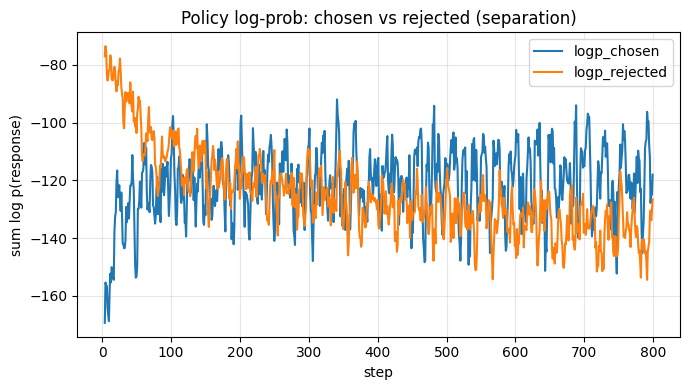

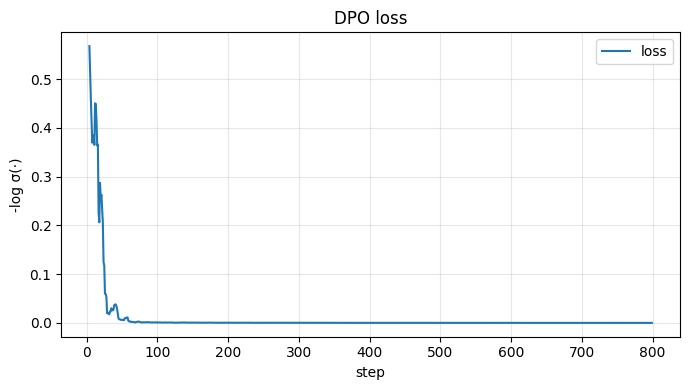

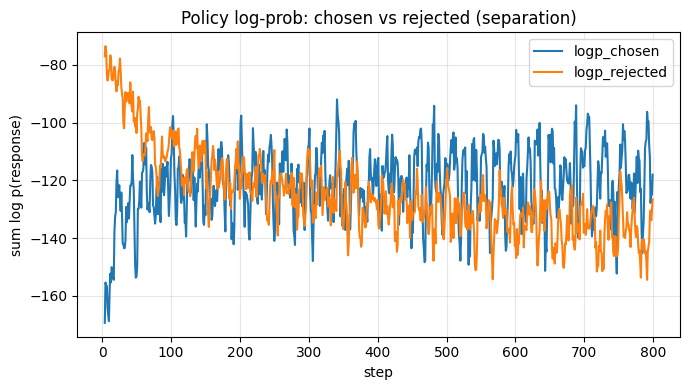

In [6]:
fig_loss = plot_curves(logger, ["loss"], title="DPO loss", ylabel="-log σ(·)", smooth=5)
fig_sep = plot_curves(logger, ["logp_chosen", "logp_rejected"],
                      title="Policy log-prob: chosen vs rejected (separation)",
                      ylabel="sum log p(response)", smooth=5)
fig_sep

## Before vs after: reference (SFT) vs aligned policy

Since the reference is the frozen SFT model, comparing its greedy answers to the
policy's shows what DPO changed. On this toy data the shift is toward the
fuller, on-tone "chosen" style and away from the terse/incorrect "rejected" style.

In [7]:
@torch.no_grad()
def answer(model, instruction, max_new_tokens=60):
    model.eval()
    inputs = tokenizer(format_prompt(instruction), return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                         pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:],
                            skip_special_tokens=True).strip()


for q in ["What is a lumenwright?",
          "What should I do if my lumen is fretting?",
          "Should I rush a tuning if I am in a hurry?"]:
    print(f"Q: {q}")
    print(f"  REFERENCE (SFT) : {answer(reference, q)}")
    print(f"  POLICY (DPO)    : {answer(policy, q)}\n")

Q: What is a lumenwright?


  REFERENCE (SFT) : A lumenwright is an apprentice shoemaker. A lumenwright is an educator. A lumenmaster learns craftsmanship before starting a journey. A lumenwrights hope one day they'll be able to see the light.


  POLICY (DPO)    : A lumenwright crafts lumenvarnises to breed more lumens by firing each day in the twilight labor of a first-born luminantrum and a second-born one a second-awnlumen and a second-ratelumenpreparation, then a third-born one

Q: What should I do if my lumen is fretting?


  REFERENCE (SFT) : Your lumen is fretting because its resonating too much, not from a bad mother-grat. It can be fixed by adjusting its resting tissue.


  POLICY (DPO)    : A lumen that is fretting may be taught to resonate gently or tuned-fractured, so that the fretting is not rekindled. It is called tuned-fracturing.

Q: Should I rush a tuning if I am in a hurry?


  REFERENCE (SFT) : A quick tuning is best for a new car, so you can keep it in your home while the rest are adjusted. A quick one that works for you will keep your engine humming along fine, while this one I’ll be using for this day will be on the cusp of steady-running


  POLICY (DPO)    : A quick tune is best of a slow tunger, but a first-light one remembers a last-chance grade, so it may well choose a first-light tuning before the guttering. It only takes a few days to unwind the crystal, which can then be stored for use.



In [8]:
ckpt_path = save_lora_checkpoint(
    policy, CKPT_DIR / "dpo" / "adapter.pt",
    metadata={"stage": "dpo", "epochs": EPOCHS, "lr": LR, "beta": BETA,
              "final_loss": logger.last("loss"),
              "final_accuracy": logger.last("accuracy")},
)
print("Saved:", ckpt_path)

Saved: /Users/jorgesandoval/code/llm-post-training-from-scratch/checkpoints/dpo/adapter.pt


## Recap & what's next

- Implemented DPO **from scratch**: per-sequence log-probs → implicit rewards →
  logistic preference loss, all against a **frozen reference** — no reward model.
- Watched the chosen/rejected log-prob **separation** grow and preference
  accuracy rise.
- Saved the aligned adapter to `checkpoints/dpo/adapter.pt`.

DPO aligns to preferences expressed as static pairs. The last stage instead uses
an *online, verifiable* reward.

➡️ **`04_grpo.ipynb`** — Group Relative Policy Optimization: real RL on an
arithmetic task with a checkable reward, where the **mean reward of a sampled
group** is the baseline that removes PPO's value network.